# Dependencies and Imports


In [1]:
# !pip3 install torch pytorch-lightning multiprocess

In [1]:
import warnings
warnings.filterwarnings("ignore")
# import random
import torch
import torch.nn as nn
import torch.nn.functional as F # ReLU, Softmax
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, TensorDataset #, IterableDataset, TensorDataset
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import pytorch_lightning as pl
from pytorch_lightning import seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint #, EarlyStopping
from pytorch_lightning.tuner import Tuner
from pytorch_lightning.loggers import TensorBoardLogger # WandbLogger

from functools import reduce
import numpy as np
import pandas as pd
import datetime as dt
from dateutil.relativedelta import relativedelta
from datetime import date, timedelta

import sys
sys.path.append('..')   # to load modules from parent directory
from NowcastingPipelineM import NowcastingPH_M
import dynamicfactoranalysis.dynamicfactoranalysis as dfa

# from MTSeq2One import *
from STSeq2One import STMFSeq2One, MTMFSeq2SeqLightning
from data_utils import get_dataloader_for_vintage, NowcastingLSTM_MQ, sliding_windows
from train_vintage import train_one_vintage
from evaluate_vintage import evaluate_one_vintage

# def set_seed(seed):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     # torch.backends.cudnn.deterministic = True                     # Only cuDNN convolution algorithms
#     torch.use_deterministic_algorithms(True)                        # All torch and cuDNN algorithms when available. RunTime error if not available.
#     torch.backends.cudnn.benchmark = False                          # Uses the same algorthim. May lose out on performance.
#     # torch.utils.deterministic.fill_uninitialized_memory = True    # For torch.empty() or torch.Tensor.resize()
#     os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':16:8'                 # For RNN/LSTM

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device="cpu"
print(device)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))

import os
os.chdir('..')          # to read data/Econ_Data
# print(os.getcwd())

cpu
2.6.0+cu124
True
1
0
Quadro RTX 6000


# Eval Loop

In [ ]:
# def evaluate_one_vintage(vintage, device="cpu"):
#     ### Train Scaler + Backcast/Test Data
#     kmpair = {'PE': ['CRVADER_BVN','CR_BxP_0'],'PU+': ['CRVADER_BVN','CR_BxP_0']} # kmpair = {'PE':['CR_B0']}
#     data_model = NowcastingLSTM_MQ(target='GDP')
#     train_data, target_scaler, econ_scaler, tweets_scaler = data_model.load_data(vintage=vintage,window=1000, kmpair=kmpair, with_econ=True, with_tweets=False, target_release_lag=True,scaled=True, extend=False, DFM_order=(1,0,1,0), optimize_order = False)
#     data_window = 15
#     backcast_data, _, _, _ = data_model.load_data(vintage=vintage, window=1000, kmpair=kmpair, with_econ=True, with_tweets=False, target_release_lag=True,scaled=False, extend=True, DFM_order=(1,0,1,0), optimize_order = False)
#     backcast_data = backcast_data.loc[vintage + relativedelta(months = -((vintage.month - 1) % 3) - data_window, day=31):,:]#.dropna()#.reset_index()  # get first month of same qtr last year, but get final day. Based on window = 12
#     backcast_data.iloc[:,:1] = target_scaler.transform(backcast_data.iloc[:,:1])
#     backcast_data.iloc[:,1:] = econ_scaler.transform(backcast_data.iloc[:,1:10])
#     x_encoder_backcast_in, y_decoder_backcast_in, _, _ = sliding_windows(backcast_data, seq_length=data_window+3)
#     backcastX_in = torch.Tensor(x_encoder_backcast_in)#.to(device)
#     backcastY_in = torch.Tensor(y_decoder_backcast_in)#.to(device)

#     ### Load Model
#     dim_x = 9 #trainX_in.shape[-1] # 9
#     dim_y = 1 #trainY_in.shape[-1] # 1
#     Lx = 15 #trainX_in.shape[1] # 15
#     Ty = 4 #trainY_in.shape[1] # 4
#     n_a = 4
#     n_s = 8
#     n_align = 4
#     fc_y = 4
#     dropout_rate = 0
#     freq_ratio = 3
#     bidirectional_encoder = False
#     model = STMFSeq2One(dim_x=dim_x,dim_y=dim_y,Lx=Lx,Ty=Ty,n_a=n_a,n_s=n_s,n_align=n_align,fc_y=fc_y,dropout_rate=dropout_rate,freq_ratio=freq_ratio,bidirectional_encoder=bidirectional_encoder)
#     lightning_model = MTMFSeq2SeqLightning.load_from_checkpoint(checkpoint_path=f"checkpoints/vintage_{vintage}/model.ckpt", model=model)

#     lightning_model.eval()
#     with torch.no_grad():
#             ### Check if vintage is first month in a quarter
#         if vintage.month % 3 == 1:
#             backcastY = lightning_model(backcastX_in[:,:-3],backcastY_in[:,:-1])
#             backcastY_in[:,-1] = backcastY.item() # backcastY_in = torch.cat([backcastY_in, backcastY.unsqueeze(1)], dim=1)
#         nowcastY = lightning_model(backcastX_in[:,3:],backcastY_in[:,1:])
#         nowcastY = target_scaler.inverse_transform(nowcastY)
#     return (vintage, nowcastY)

In [2]:
evaluate_one_vintage(pd.to_datetime('2022-12-31'), version='-v1')

/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


(Timestamp('2022-12-31 00:00:00'), array([[6.89057552]]))

In [2]:
# import multiprocess as mp
# import functools
# from mixfreqlstm.evaluate_vintage import evaluate_one_vintage
# from mixfreqlstm.data_utils import sliding_windows, NowcastingLSTM_MQ

vintage_ids = list(pd.date_range(start="2017-01-31", end="2023-01-01", freq="ME"))
results = []
for vintage in vintage_ids:
    result = evaluate_one_vintage(vintage, version='-v5')
    results.append(result)
# with mp.get_context('spawn').Pool(processes=3) as pool: #.get_context('spawn')
#     results = pool.map(functools.partial(evaluate_one_vintage, device=device), vintage_ids)


results_df = pd.DataFrame(results, columns=["Vintage", "Prediction"])
results_df["Prediction"] = results_df["Prediction"].apply(lambda x: x[0][0])  # Extract the scalar value from the array
results_df = results_df.set_index("Vintage")
# results_df.to_csv("results_E_e50.csv", index=False)
gdp = pd.read_csv('Results/Original/DFM_Opt_W1000_GDP_E_summary.csv', parse_dates=['date'], index_col=[0])[['Actual_Q']]
results_df = pd.concat([results_df, gdp], axis=1)
results_df.to_csv('results_T_e150_w27.csv')
display(results_df)

/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/btiu/Documents/Research/Tw

,Prediction,Actual_Q
2017-01-31,5.518694,6.374133
2017-02-28,5.161027,6.374133
2017-03-31,5.318699,6.374133
2017-04-30,6.347373,7.177099
2017-05-31,6.435264,7.177099
...,...,...
2022-08-31,4.446268,7.635937
2022-09-30,4.390065,7.635937
2022-10-31,3.534736,7.225544
2022-11-30,6.403074,7.225544


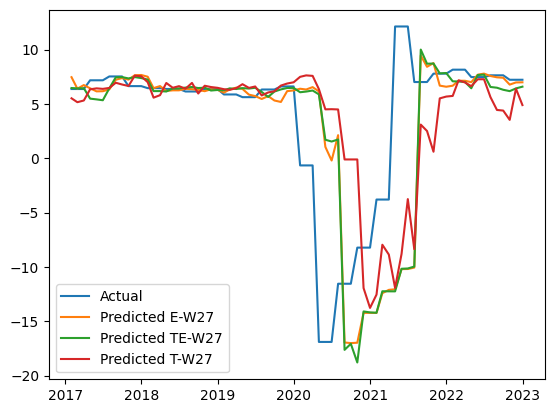

In [5]:
### W27
import matplotlib.pyplot as plt
e150_w27 = pd.read_csv('results_E_e150_w27.csv', parse_dates=[0], index_col=[0])
te150_w27 = pd.read_csv('results_TE_e150_w27.csv', parse_dates=[0], index_col=[0])
t150_w27 = pd.read_csv('results_T_e150_w27.csv', parse_dates=[0], index_col=[0])
plt.plot(e150_w27.index, e150_w27['Actual_Q'], label='Actual')
plt.plot(e150_w27.index, e150_w27['Prediction'], label='Predicted E-W27')
plt.plot(te150_w27.index, te150_w27['Prediction'], label='Predicted TE-W27')
plt.plot(t150_w27.index, t150_w27['Prediction'], label='Predicted T-W27')
plt.legend()

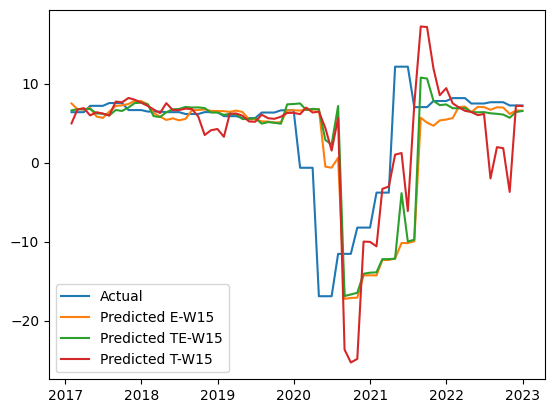

In [3]:
### W15
import matplotlib.pyplot as plt
e150_w15 = pd.read_csv('results_E_e150_w15.csv', parse_dates=[0], index_col=[0])
te150_w15 = pd.read_csv('results_TE_e150_w15.csv', parse_dates=[0], index_col=[0])
t150_w15 = pd.read_csv('results_T_e150_w15.csv', parse_dates=[0], index_col=[0])
plt.plot(e150_w15.index, e150_w15['Actual_Q'], label='Actual')
plt.plot(e150_w15.index, e150_w15['Prediction'], label='Predicted E-W15')
plt.plot(te150_w15.index, te150_w15['Prediction'], label='Predicted TE-W15')
plt.plot(t150_w15.index, t150_w15['Prediction'], label='Predicted T-W15')
plt.legend()

In [7]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(results_df['Actual_Q'], results_df['Prediction']))
print(f"RMSE: {rmse}")

RMSE: 7.057210453585524


In [49]:
import os
import shutil

# Define the directories
tb_logs_dir = "tb_logs"
checkpoint_dir = "checkpoints"

# Delete version 1 logs in tb_logs
if os.path.exists(tb_logs_dir):
    for item in os.listdir(tb_logs_dir):
        if "version_1" in os.listdir(tb_logs_dir + '/' + item):
            path = os.path.join(tb_logs_dir, item, "version_1")
            if os.path.isdir(path):
                shutil.rmtree(path)
                print(f"Deleted: {path}")

# Delete model-v1 directories in checkpoint
if os.path.exists(checkpoint_dir):
    for item in os.listdir(checkpoint_dir):
        if "model-v1.ckpt" in os.listdir(checkpoint_dir + '/' + item):
            path = os.path.join(checkpoint_dir, item, "model-v1.ckpt")
            os.remove(path)
            print(f"Deleted: {path}")

Deleted: tb_logs/vintage_2017-11-30 00:00:00/version_1
Deleted: tb_logs/vintage_2021-10-31 00:00:00/version_1
Deleted: tb_logs/vintage_2018-12-31 00:00:00/version_1
Deleted: tb_logs/vintage_2019-04-30 00:00:00/version_1
Deleted: tb_logs/vintage_2021-09-30 00:00:00/version_1
Deleted: tb_logs/vintage_2022-03-31 00:00:00/version_1
Deleted: tb_logs/vintage_2021-08-31 00:00:00/version_1
Deleted: tb_logs/vintage_2020-03-31 00:00:00/version_1
Deleted: tb_logs/vintage_2022-08-31 00:00:00/version_1
Deleted: tb_logs/vintage_2018-04-30 00:00:00/version_1
Deleted: tb_logs/vintage_2021-01-31 00:00:00/version_1
Deleted: tb_logs/vintage_2020-12-31 00:00:00/version_1
Deleted: tb_logs/vintage_2022-07-31 00:00:00/version_1
Deleted: tb_logs/vintage_2019-01-31 00:00:00/version_1
Deleted: tb_logs/vintage_2018-08-31 00:00:00/version_1
Deleted: tb_logs/vintage_2018-11-30 00:00:00/version_1
Deleted: tb_logs/vintage_2018-05-31 00:00:00/version_1
Deleted: tb_logs/vintage_2017-10-31 00:00:00/version_1
Deleted: t

# Single output LSTM

In [9]:
### Train & Backcast Data
vintage = pd.to_datetime('2017-01-31')
kmpair = {'PE': ['CRVADER_BVN','CR_BxP_0'],'PU+': ['CRVADER_BVN','CR_BxP_0']} # kmpair = {'PE':['CR_B0']}

data_model = NowcastingLSTM_MQ(target='GDP')
train_data, target_scaler, econ_scaler, tweets_scaler = data_model.load_data(vintage=vintage,window=1000, kmpair=kmpair, with_econ=True, with_tweets=False, target_release_lag=True,scaled=True, extend=False, DFM_order=(1,0,1,0), optimize_order = False)
# train_data = train_data.dropna()
display(train_data)

# data_window = 15
# # backcast_vintage = vintage - relativedelta(months=1)
# backcast_data, _, _, _ = data_model.load_data(vintage=vintage, window=1000, kmpair=kmpair, with_econ=True, with_tweets=False, target_release_lag=True,scaled=False, extend=True, DFM_order=(1,0,1,0), optimize_order = False)
# backcast_data = backcast_data.loc[vintage + relativedelta(months = -((vintage.month - 1) % 3) - data_window, day=31):,:]#.dropna()#.reset_index()  # get first month of same qtr last year, but get final day. Based on window = 12
# backcast_data.iloc[:,:1] = target_scaler.transform(backcast_data.iloc[:,:1])
# backcast_data.iloc[:,1:] = econ_scaler.transform(backcast_data.iloc[:,1:10])
# display(backcast_data)
# # model.load_target(vintage=pd.to_datetime('2017-01-31'), target='GDP', growth=True, quarterly=True, freq='M', target_release_lag=False)

# x_encoder_backcast_in, y_decoder_backcast_in, _, _ = sliding_windows(backcast_data, seq_length=18)
# backcastX_in = torch.Tensor(x_encoder_backcast_in)#.to(device)
# backcastY_in = torch.Tensor(y_decoder_backcast_in)#.to(device)

,target,ECN.pseiclose_YoY,ECN.tbill_usd90,ECN.phpusd_YoY,ECN.tdr_php360,ECN.govtexpt_YoY,ECN.m1_YoY,ECN.IPI_YoY,ECN.imports_YoY,ECN.exports_YoY
date,,,,,,,,,,
2010-01,1.352012,2.517938,-0.284098,-0.548772,1.223782,0.347837,0.451220,3.064697,1.600958,2.223921
2010-02,1.352012,2.561692,0.154962,-0.585722,1.301379,-0.520349,1.265573,2.685477,1.289299,2.224540
2010-03,1.352012,2.367615,0.418398,-1.198938,1.317140,1.784152,2.228285,1.909728,2.170977,2.313774
2010-04,1.240001,2.208546,0.418398,-1.584540,1.071013,0.910811,2.924937,2.504871,2.937054,1.365598
2010-05,1.240001,1.095018,0.418398,-0.874627,1.147397,1.320597,1.620550,1.983715,1.694440,1.903395
...,...,...,...,...,...,...,...,...,...,...
2016-09,0.743091,-0.411816,1.472142,0.278561,-0.819198,1.416951,-0.299419,0.545319,0.553385,0.061368
2016-10,NaN,-0.805990,1.999014,0.872012,-0.739177,-1.556527,-0.305628,0.402307,0.030415,0.162495
2016-11,NaN,-1.143887,3.228382,0.931398,-0.634906,1.393502,-1.039473,1.156271,0.784309,-0.733466


In [ ]:
x_encoder_in, y_decoder_in, x_target, y_target = sliding_windows(train_data, seq_length=15)
print(x_encoder_in.shape) # (timesteps, seq_length, dim_x)
print(y_decoder_in.shape) # (timesteps, dim_y)
print(x_target.shape)
print(y_target.shape)
trainX_in = torch.Tensor(x_encoder_in)#.to(device)
trainY_in = torch.Tensor(y_decoder_in)#.to(device)
trainX_out = torch.Tensor(y_target)#.to(device)
trainY_out = torch.Tensor(y_target)#.to(device)

x_encoder_backcast_in, y_decoder_backcast_in, _, _ = sliding_windows(backcast_data, seq_length=18)
backcastX_in = torch.Tensor(x_encoder_backcast_in)#.to(device)
backcastY_in = torch.Tensor(y_decoder_backcast_in)#.to(device)
print(backcastX_in.shape) # (timesteps, seq_length, dim_x)
print(backcastY_in.shape) # (timesteps, dim_y)

###
get_dataloader_for_vintage(pd.to_datetime('2017-01-31'))

torch.Size([1, 18, 9])
torch.Size([1, 5, 1])


In [ ]:
seed_everything(42, workers=True)

# Prepare the dataset and dataloader
train_dataset = TensorDataset(trainX_in, trainY_in, trainY_out)
train_loader = DataLoader(train_dataset, batch_size=2000, shuffle=True, num_workers=8)

# Initialize the model
dim_x = trainX_in.shape[-1] # 9
dim_y = trainY_in.shape[-1] # 1
Lx = trainX_in.shape[1] # 15
Ty = trainY_in.shape[1] # 4
n_a = 128
n_s = 256
n_align = 16
fc_y = 128
dropout_rate = 0.4
freq_ratio = 3
bidirectional_encoder = False

model = STMFSeq2One( 
    dim_x=dim_x,
    dim_y=dim_y,
    Lx=Lx,
    Ty=Ty,
    n_a=n_a,
    n_s=n_s,
    n_align=n_align,
    fc_y=fc_y,
    dropout_rate=dropout_rate,
    freq_ratio=freq_ratio,
    bidirectional_encoder=bidirectional_encoder,
)

# Initialize the Lightning module
lightning_model = MTMFSeq2SeqLightning(model)#.to(device)
lr_monitor = LearningRateMonitor(logging_interval='step')

# Find learning rate and train model with new learning rate
trainer = pl.Trainer(max_epochs=150, accelerator='auto',log_every_n_steps=1, callbacks=[lr_monitor], deterministic=True)
tuner = Tuner(trainer)
# lr_finder = tuner.lr_find(lightning_model, train_loader)
# lightning_model.hparams.lr = lr_finder.suggestion()
trainer.fit(lightning_model, train_loader)

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Finding best initial lr:  90%|█████████ | 90/100 [00:28<00:03,  3.18it/s]
LR finder stopped early after 90 steps due to diverging loss.
Learning rate set to 0.001584893192461114
Restoring states from the checkpoint path at /home/btiu/Documents/Research/TweetsNowcast/.lr_find_ea199354-f242-4462-ab5f-5e080e611004.ckpt
Restored all states from the checkpoint at /home/btiu/Documents/Research/TweetsNowcast/.lr_find_ea199354-f242-4462-ab5f-5e080e611004.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | STMFSeq2One | 506 K  | train
1 | criterion | MSELoss     | 0      | train
--------------------------------------------------
506 K     Trainable params
0         Non-trainable params
506 K     Total params
2.027     

Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s, v_num=5, train_loss=0.0135] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s, v_num=5, train_loss=0.0135]


In [ ]:
for vintage in pd.date_range(start="2017-01-31", end="2017-04-01", freq="ME"):
    print(train_one_vintage(vintage, device="cpu"))

In [ ]:
import multiprocess as mp
import functools
from mixfreqlstm.train_vintage import train_one_vintage
import pandas as pd

device = 'cpu'
vintage_ids = list(pd.date_range(start="2017-01-31", end="2017-04-01", freq="ME"))
with mp.get_context('spawn').Pool(processes=3) as pool:
    results = pool.map(functools.partial(train_one_vintage, device=device), vintage_ids)
print("\n".join(results))

In [ ]:
# def backcast_one_vintage(vintage, device="cpu"):
#     seed_everything(42, workers=True)
#     dataloader, target_scaler, econ_scaler, tweet_scaler, = get_dataloader_for_vintage(vintage, mode="train")
#     # Initialize the model
#     dim_x = trainX_in.shape[-1] # 9
#     dim_y = trainX_in.shape[-1] # 9
#     Lx = trainX_in.shape[1] # 15
#     Ty = trainX_in.shape[1] # 15
#     n_a = 128
#     n_s = 256
#     n_align = 16
#     fc_y = 128
#     dropout_rate = 0.4
#     freq_ratio = 3
#     bidirectional_encoder = False
#     model = STMFSeq2One(dim_x=dim_x,dim_y=dim_y,Lx=Lx,Ty=Ty,n_a=n_a,n_s=n_s,n_align=n_align,fc_y=fc_y,dropout_rate=dropout_rate,freq_ratio=freq_ratio,bidirectional_encoder=bidirectional_encoder)
#     lightning_model = MTMFSeq2SeqLightning(model)
#     # Load the best model
#     checkpoint = torch.load(f"checkpoints/vintage_{vintage}/model.ckpt")
#     model.load_state_dict(checkpoint['state_dict'])
#     model.eval()
#     # Backcast the data
#     backcast_data = backcast_data.dropna()
#     x_encoder_backcast_in, y_decoder_backcast_in, _, _ = sliding_windows(backcast_data, seq_length=15)
#     backcastX_in = Variable(torch.Tensor(x_encoder_backcast_in))#.to(device)
#     backcastY_in = Variable(torch.Tensor(y_decoder_backcast_in))#.to(device)
#     backcastX_in = backcastX_in.to(device)
#     backcastY_in = backcastY_in.to(device)
#     with torch.no_grad():
#         y_backcast = model(backcastX_in, backcastY_in)
    #     y_backcast = y_backcast.cpu().numpy()
#     y_backcast = target_scaler.inverse_transform(y_backcast)
#     y_backcast = pd.DataFrame(y_backcast, columns=['GDP'], index=backcast_data.index)
#     y_backcast = y_backcast.reset_index()
#     y_backcast['date'] = y_backcast['date'].dt.to_period('M')
#     y_backcast = y_backcast.set_index('date')
#     y_backcast = y_backcast.loc[vintage - relativedelta(months=1) + relativedelta(months=-((vintage.month - 1) % 3) - data_window, day=31):,:]
#     y_backcast = y_backcast.dropna()
#     y_backcast = y_backcast.reset_index()
#     return y_backcast
# for vintage in pd.date_range(start="2017-01-31", end="2023-01-31", freq="M"):
#     print(backcast_one_vintage(vintage, device="cpu"))

In [8]:
# Set the model to evaluation mode
lightning_model.eval()
# Perform inference on backcast data
with torch.no_grad():
    backcasts = lightning_model(torch.Tensor(x_encoder_backcast_in), torch.Tensor(y_decoder_backcast_in))
backcasts_np = backcasts.cpu().numpy()
backcasts_inverse = target_scaler.inverse_transform(backcasts_np)

# Display the backcasts
print("Backcasts (scaled):", backcasts_np)
print("Backcasts (original scale):", backcasts_inverse)

Backcasts (scaled): [[0.61162806]]
Backcasts (original scale): [[7.1591253]]


In [9]:
test_data, _, _, _ = data_model.load_data(vintage=vintage, window=1000, kmpair=kmpair, with_econ=True, with_tweets=False, target_release_lag=True,scaled=False, extend=True, DFM_order=(1,0,1,0), optimize_order = False)
test_data = test_data.loc[vintage + relativedelta(months = -((vintage.month - 1) % 3) - data_window, day=31):,:]#.dropna()#.reset_index()  # get first month of same qtr last year, but get final day. Based on window = 12
test_data.iloc[:,:1] = target_scaler.transform(test_data.iloc[:,:1])
test_data.iloc[:,1:] = econ_scaler.transform(test_data.iloc[:,1:10])
display(test_data)
x_encoder_test_in, y_decoder_test_in, _ = sliding_windows(test_data, seq_length=15)
y_decoder_test_in[:, -1, :] = backcasts_np

/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['kmpair', 'with_econ', 'with_tweets', 'target_release_lag']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method powell is: xtol, ftol, maxfun, start_direc. The list of unsupported keyword arguments passed include: target_release_lag, with_econ, with_tweets,

,target,ECN.pseiclose_YoY,ECN.tbill_usd90,ECN.phpusd_YoY,ECN.tdr_php360,ECN.govtexpt_YoY,ECN.m1_YoY,ECN.IPI_YoY,ECN.imports_YoY,ECN.exports_YoY
date,,,,,,,,,,
2016-01,0.426368,-1.769963,1.823390,1.338958,-0.620356,-0.673741,-1.543056,-0.248293,0.744833,-0.595717
2016-02,0.426368,-1.808455,1.911202,1.591316,-0.590045,0.288191,-1.443924,0.596098,-0.922067,-0.660685
2016-03,0.426368,-1.512559,0.857458,1.047783,-0.546397,0.602895,-0.157781,-0.043148,0.503029,-1.265490
2016-04,0.827599,-1.435784,0.945270,0.856488,-0.668854,0.625993,-0.613475,0.277751,1.907230,-0.661165
2016-05,0.827599,-1.158421,1.999014,1.003168,-0.690679,0.688719,-0.564785,-0.008880,2.692099,-0.540582
2016-06,0.827599,-0.847725,1.296518,0.664015,-0.740389,-1.466092,-0.357619,0.316361,0.851245,-1.025924
2016-07,0.743091,-0.709768,1.384330,0.803956,-0.825261,-0.660958,-0.258367,0.628280,-0.464733,-1.133776
2016-08,0.743091,-0.467543,1.911202,0.218995,-0.752514,-0.090556,0.414840,0.762093,0.403451,-0.562101
2016-09,0.743091,-0.411816,1.472142,0.278561,-0.819198,1.416951,-0.299419,0.545319,0.553385,0.061368


In [10]:
# Set the model to evaluation mode
lightning_model.eval()
# Perform inference on backcast data
with torch.no_grad():
    predictions = lightning_model(torch.Tensor(x_encoder_test_in), torch.Tensor(y_decoder_test_in))
predictions_np = predictions.cpu().numpy()
predictions_inverse = target_scaler.inverse_transform(predictions_np)

# Display the predictions
print("Predictions (scaled):", predictions_np)
print("Predictions (original scale):", predictions_inverse)

Predictions (scaled): [[0.29147112]]
Predictions (original scale): [[6.743473]]


In [ ]:
# # trainer.checkpoint_callback.last_model_path
# trainer = pl.Trainer(
#     max_epochs=200,
#     accelerator='auto',
#     log_every_n_steps=1,
# )
# trainer.fit(lightning_model, train_loader, ckpt_path = 'lightning_logs/version_50/checkpoints/epoch=99-step=100.ckpt')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at lightning_logs/version_50/checkpoints/epoch=99-step=100.ckpt
/home/btiu/Documents/Research/TweetsNowcast/.venv/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:362: The dirpath has changed from '/home/btiu/Documents/Research/TweetsNowcast/lightning_logs/version_50/checkpoints' to '/home/btiu/Documents/Research/TweetsNowcast/lightning_logs/version_52/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | MTMFSeq2Seq | 506 K  | train
1 | criterion | MSELoss     | 0      | train
--------------------------------------------------
5

Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s, v_num=52, train_loss=0.0303]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 1/1 [00:00<00:00,  2.74it/s, v_num=52, train_loss=0.0303]


In [1]:
%reload_ext tensorboard
%tensorboard --logdir="..tb_logs" --port=8000

Launching TensorBoard...

# Dual output LSTM

In [ ]:
### seq2one x, y

class PreAttnEncoder(nn.Module):
    """Pre-attention Encoder module"""
    def __init__(self, dim_x, fc_dim, n_a, dropout_rate=0.2, bidirectional_encoder=False, l1reg=1e-5, l2reg=1e-4):
        super(PreAttnEncoder, self).__init__()
        self.bidirectional_encoder = bidirectional_encoder
        self.l1reg = l1reg
        self.l2reg = l2reg

        self.lstm = nn.LSTM(input_size=dim_x, hidden_size=n_a, batch_first=True, bidirectional=bidirectional_encoder)
        self.ffn1 = nn.Linear(n_a * (2 if bidirectional_encoder else 1), fc_dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.ffn2 = nn.Linear(fc_dim, dim_x) ### add regularizer

    def forward(self, x):
        """
        Forward pass for the encoder
        Args:
            x: (tensor) shape (batch_size, Lx, dim_x)
        Returns:
            x_pred: (tensor), the next step prediction for x (batch_size, dim_x)
            a: (tensor) sequence of LSTM hidden states, (batch_size, Lx, n_a)
        """
        a, _ = self.lstm(x)
        x_pred = F.relu(self.ffn1(a[:, -1, :]))
        x_pred = self.dropout(x_pred)
        x_pred = self.ffn2(x_pred)
        return x_pred, a


class OneStepAttn(nn.Module):
    """Attention alignment module"""
    def __init__(self, n_a, n_s, n_align):
        super(OneStepAttn, self).__init__()
        self.densor1 = nn.Linear(n_a + n_s, n_align)
        self.densor2 = nn.Linear(n_align, 1)

    def forward(self, a, s_prev):
        """
        Performs one step of attention
        Args:
            a: hidden state from the pre-attention LSTM, shape = (batch_size, Lx, n_a)
            s_prev: previous hidden state of the post-attention LSTM, shape = (batch_size, n_s)
        Returns:
            context: context vector, input of the next post-attention LSTM cell
        """
        s_prev = s_prev.unsqueeze(1).repeat(1, a.size(1), 1)  # (batch_size, Lx, n_s)
        concat = torch.cat((a, s_prev), dim=-1)  # (batch_size, Lx, n_a + n_s)
        e = torch.tanh(self.densor1(concat))
        energies = F.relu(self.densor2(e))  # (batch_size, Lx, 1)
        alphas = F.softmax(energies, dim=1)  # (batch_size, Lx, 1)
        context = torch.bmm(alphas.transpose(1,2), a).squeeze(1)  # (batch_size, n_a)
        return context


class MTMFSeq2One(nn.Module):
    def __init__( self, Lx, dim_x, Ty, dim_y, n_a, n_s, n_align, fc_x, fc_y, dropout_rate, freq_ratio=3, bidirectional_encoder=False, l1reg=1e-5, l2reg=1e-4):
        super(MTMFSeq2One, self).__init__()
        self.dim_x = dim_x
        self.dim_y = dim_y
        self.Lx = Lx
        self.Ty = Ty
        self.n_a = n_a
        self.n_s = n_s
        self.n_align = n_align
        self.fc_x = fc_x
        self.fc_y = fc_y
        self.freq_ratio = freq_ratio
        self.bidirectional_encoder = bidirectional_encoder
        self.l1reg = l1reg
        self.l2reg = l2reg

        # Encoder
        self.pre_attn = PreAttnEncoder(dim_x, fc_x, n_a, dropout_rate, bidirectional_encoder, l1reg, l2reg)
        # Attention alignment model
        self.one_step_attention = OneStepAttn(n_a, n_s, n_align)
        # Decoder
        self.post_attn = nn.LSTMCell(n_a + dim_y, n_s)
        self.ffn1 = nn.Linear(n_s, fc_y)
        self.dropout = nn.Dropout(dropout_rate)
        self.ffn2 = nn.Linear(fc_y, dim_y) ### add regularizer?

    def initialize_state(self, batch_size, dim):
        return torch.zeros(batch_size, dim) ### faster to initialize specific device?

    def forward(self, x_encoder_in, y_decoder_in):
        """
        Forward pass
        Args:
            batch_inputs: tuple of (x, y) where
                x: encoder input, shape (batch_size, Lx, dim_x)
                y: decoder input, shape (batch_size, Ty, dim_y)
        Returns:
            x_pred: prediction for x
            y_pred: prediction for y
        """
        batch_size = x_encoder_in.size(0)

        # Stage 1: Pre-attention encoding
        x_pred, a = self.pre_attn(x_encoder_in)

        # Stage 2: Attention-based decoding
        s = self.initialize_state(batch_size, self.n_s).to(x_encoder_in.device)
        c = self.initialize_state(batch_size, self.n_s).to(x_encoder_in.device)
        for t in range(self.Ty):
            a_idx = int((t + 1) * self.freq_ratio - 1)
            a_to_attend = a[:, (a_idx - self.freq_ratio + 1):(a_idx + 1), :]
            context = self.one_step_attention(a_to_attend, s)
            post_attn_input = torch.cat((context, y[:, t, :]), dim=-1)
            s, c = self.post_attn(post_attn_input, (s, c))

        y_pred = F.relu(self.ffn1(s))
        y_pred = self.dropout(y_pred)
        y_pred = self.ffn2(y_pred)
        return x_pred, y_pred